In [ ]:
!pip install ptflops

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 146MB/s] 


Model Parameters: 4203313
Model Size (MB): 16.034366607666016
FLOPs: 230.04 MMac


100%|██████████| 4665/4665 [25:35<00:00,  3.04it/s]



Epoch: 1
Train Loss: 1.1233472579553132
Val Accuracy: 0.7080497492028567
Val AUROC: 0.8702647756552585


...


Epoch: 5
Train Loss: 0.6489713489194775
Val Accuracy: 0.8587331481101643
Val AUROC: 0.9032127283039976


100%|██████████| 4665/4665 [15:17<00:00,  5.08it/s]



Epoch: 6
Train Loss: 0.6190286910243229
Val Accuracy: 0.8663596188629287
Val AUROC: 0.9166948301089467


100%|██████████| 4665/4665 [15:25<00:00,  5.04it/s]



Epoch: 7
Train Loss: 0.5983114450610975
Val Accuracy: 0.830707266590837
Val AUROC: 0.9123625722261302
Early stopping

TEST RESULTS
Accuracy: 0.8812563945160631
Recall: 0.7538461538461538
F1: 0.0166073546856465
AUROC: 0.901420094095025
MCC: 0.07139786308060737
Kappa: 0.01401340413476404
Confusion Matrix
 [[43018  5787]
 [   16    49]]


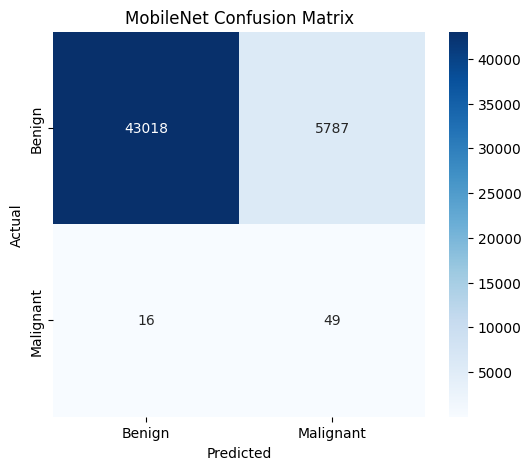

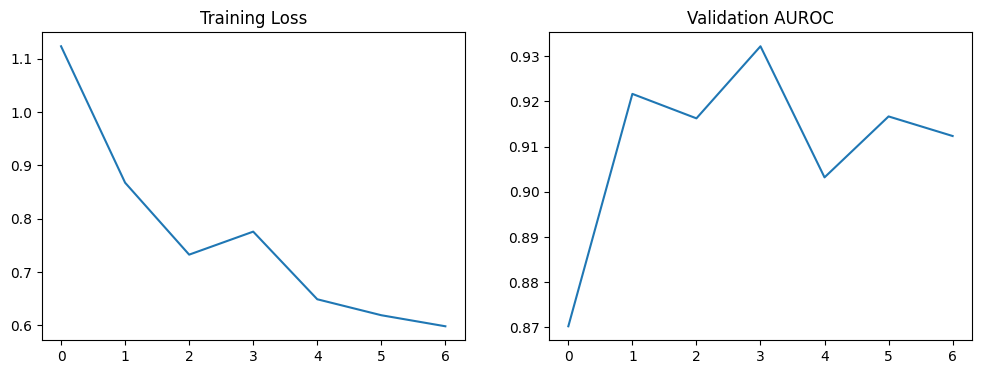

Average inference time: 0.007631680965423584


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import os

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score
)

from ptflops import get_model_complexity_info

# CONFIG

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIG = {
    "batch_size": 64,
    "epochs": 20,
    "lr": 1e-4,
    "img_size": 224,
    "patience": 3
}

INDEX_PATH = "/kaggle/input/datasets/fallen001/kagglefinaldataset/final_dataset_index_fixed.csv"

print("Using device:", DEVICE)

# DATASET
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.base_dir = "/kaggle/input/competitions/isic-2024-challenge/train-image/image"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---- PATH FIX ----
        filename = os.path.basename(row["path"])
        img_path = os.path.join(self.base_dir, filename)
        # ------------------

        assert os.path.exists(img_path), f"Missing image: {img_path}"

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(row["target"], dtype=torch.float32)
        return image, label


# TRANSFORMS

train_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.Normalize(),
    ToTensorV2()
])

# LOAD DATA

df = pd.read_csv(INDEX_PATH)

train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

train_loader = DataLoader(
    ISICDataset(train_df, train_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    ISICDataset(val_df, val_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    ISICDataset(test_df, val_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)

# CLASS WEIGHT

mal = train_df["target"].sum()
ben = len(train_df) - mal

pos_weight = ben / mal

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE)
)

# MODEL

model = models.mobilenet_v3_large(weights="IMAGENET1K_V1")

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 1)

model = model.to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])

# MODEL SIZE

params = sum(p.numel() for p in model.parameters())
print("Model Parameters:", params)
print("Model Size (MB):", params*4/(1024**2))

# FLOPS

macs, _ = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=True,
    print_per_layer_stat=False
)

print("FLOPs:", macs)

# METRIC STORAGE

train_losses=[]
val_accs=[]
val_aucs=[]

# EVALUATION

def evaluate(model,loader):

    model.eval()

    y_true=[]
    y_pred=[]
    y_prob=[]

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs>=0.5).astype(int)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    acc = accuracy_score(y_true,y_pred)
    recall = recall_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)
    auc = roc_auc_score(y_true,y_prob)

    mcc = matthews_corrcoef(y_true,y_pred)
    kappa = cohen_kappa_score(y_true,y_pred)

    cm = confusion_matrix(y_true,y_pred)

    return acc,recall,f1,auc,mcc,kappa,cm

# TRAINING

best_auc=0
counter=0

for epoch in range(CONFIG["epochs"]):

    model.train()

    running_loss=0

    for images,labels in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss/len(train_loader)

    val_acc,val_recall,val_f1,val_auc,val_mcc,val_kappa,val_cm = evaluate(model,val_loader)

    train_losses.append(train_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print("\nEpoch:",epoch+1)
    print("Train Loss:",train_loss)
    print("Val Accuracy:",val_acc)
    print("Val AUROC:",val_auc)

    if val_auc>best_auc:

        best_auc=val_auc
        counter=0

        torch.save(model.state_dict(),"best_mobilenet.pth")

    else:

        counter+=1

    if counter>=CONFIG["patience"]:

        print("Early stopping")
        break

# TEST RESULTS

model.load_state_dict(torch.load("best_mobilenet.pth"))

test_acc,test_recall,test_f1,test_auc,test_mcc,test_kappa,test_cm = evaluate(model,test_loader)

print("\nTEST RESULTS")

print("Accuracy:",test_acc)
print("Recall:",test_recall)
print("F1:",test_f1)
print("AUROC:",test_auc)
print("MCC:",test_mcc)
print("Kappa:",test_kappa)

print("Confusion Matrix\n",test_cm)

# CONFUSION MATRIX HEATMAP

plt.figure(figsize=(6,5))

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNet Confusion Matrix")

plt.show()

# TRAINING GRAPHS

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs)
plt.title("Validation AUROC")

plt.show()

# INFERENCE TIME

model.eval()

dummy = torch.randn(1,3,224,224).to(DEVICE)

start=time.time()

for _ in range(100):
    model(dummy)

end=time.time()

print("Average inference time:",(end-start)/100)